<a href="https://colab.research.google.com/github/ramyaa-hegde/flyrank-ml-internship-tasks/blob/main/work/notebooks/w04_signal_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ramyaa-hegde/flyrank-ml-internship-tasks/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

=== Distribution Audit ===
March content-client candidates: 101441


,min,median,p95,p99,max
march_impressions,100.000,786.000,11113.000,29371.000,617124.000
march_clicks,0.000,1.000,34.000,103.000,5668.000
march_ctr,0.000,0.001,0.010,0.019,0.156
march_avg_position,0.102,8.959,45.207,70.144,113.390
march_scroll_events,0.000,1.000,16.000,41.000,667.000
march_sessions_social,0.000,0.000,0.000,0.000,20.000


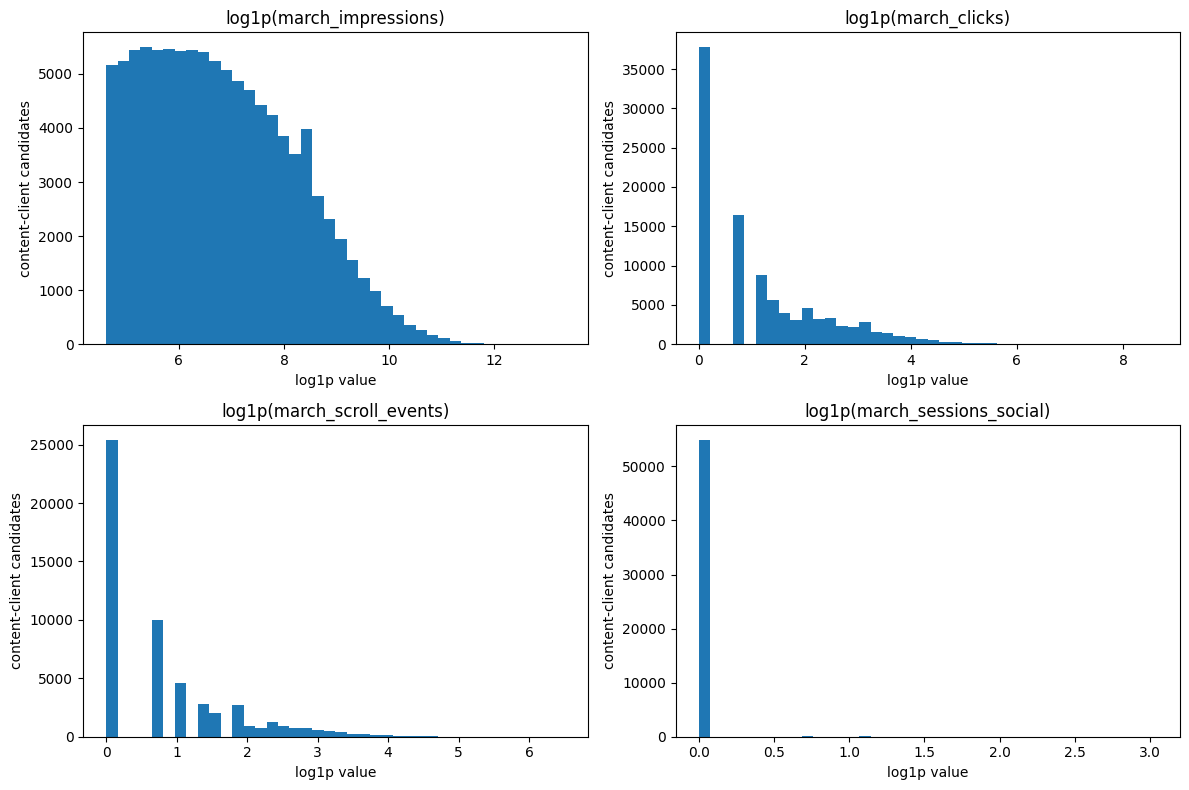

Interpretation rule: if p99 is much larger than the median, the field is heavy-tailed. Later signal tests will use buckets, weighted rates, or log/rank-aware comparisons instead of raw averages.


In [6]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import userdata

hf_token = userdata.get("HF_TOKEN")
if not hf_token:
    raise ValueError("Add HF_TOKEN in Colab Secrets and enable Notebook access.")

con = duckdb.connect()
con.execute(
    "CREATE OR REPLACE SECRET hf "
    f"(TYPE huggingface, TOKEN '{hf_token}')"
)

REL = "hf://datasets/FlyRank/internship-warehouse"
MARCH = f"{REL}/fact_content_daily_performance/month=2026-03/*.parquet"

audit_sql = f"""
SELECT
    client_hash_id,
    content_hash_id,
    SUM(gsc_impressions) AS march_impressions,
    SUM(gsc_clicks) AS march_clicks,
    SUM(gsc_clicks)::DOUBLE
        / NULLIF(SUM(gsc_impressions), 0) AS march_ctr,
    AVG(NULLIF(gsc_avg_position, 0)) AS march_avg_position,
    SUM(
        CASE
            WHEN ga4_data_available IS TRUE
            THEN scroll_events
        END
    ) AS march_scroll_events,
    SUM(
        CASE
            WHEN ga4_data_available IS TRUE
            THEN sessions_social
        END
    ) AS march_sessions_social,
    COUNT(*) AS observed_days
FROM read_parquet('{MARCH}')
WHERE gsc_data_available IS TRUE
GROUP BY 1, 2
HAVING
    SUM(gsc_impressions) >= 100
    AND AVG(NULLIF(gsc_avg_position, 0)) IS NOT NULL
"""

audit_df = con.execute(audit_sql).df()

distribution_columns = [
    "march_impressions",
    "march_clicks",
    "march_ctr",
    "march_avg_position",
    "march_scroll_events",
    "march_sessions_social",
]

quantiles = audit_df[distribution_columns].quantile(
    [0.00, 0.50, 0.95, 0.99, 1.00]
).T

quantiles.columns = [
    "min",
    "median",
    "p95",
    "p99",
    "max",
]

print("=== Distribution Audit ===")
print("March content-client candidates:", len(audit_df))
display(quantiles.round(3))

traffic_columns = [
    "march_impressions",
    "march_clicks",
    "march_scroll_events",
    "march_sessions_social",
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for axis, column in zip(axes.flat, traffic_columns):
    values = audit_df[column].dropna()
    axis.hist(np.log1p(values), bins=40)
    axis.set_title(f"log1p({column})")
    axis.set_xlabel("log1p value")
    axis.set_ylabel("content-client candidates")

plt.tight_layout()
plt.show()

print(
    "Interpretation rule: if p99 is much larger than the median, "
    "the field is heavy-tailed. Later signal tests will use buckets, "
    "weighted rates, or log/rank-aware comparisons instead of raw averages."
)

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

In [7]:
import pandas as pd

def weighted_ctr(group):
    return group["march_clicks"].sum() / group["march_impressions"].sum()

# Signal test 1: position bucket versus weighted CTR
position_df = audit_df.copy()

position_df["position_bucket"] = pd.cut(
    position_df["march_avg_position"],
    bins=[0, 3, 10, 20, 50, float("inf")],
    labels=["1-3", "4-10", "11-20", "21-50", "51+"],
    include_lowest=True,
)

signal_1 = (
    position_df.groupby("position_bucket", observed=True)
    .apply(
        lambda group: pd.Series({
            "n": len(group),
            "total_impressions": group["march_impressions"].sum(),
            "weighted_ctr": weighted_ctr(group),
            "median_position": group["march_avg_position"].median(),
        })
    )
    .reset_index()
)

print("=== Signal Test 1: Position bucket and weighted CTR ===")
display(signal_1.round(4))

# Signal test 2: February-style engagement proxy —
# March scroll-event buckets versus weighted CTR.
scroll_df = audit_df[
    audit_df["march_scroll_events"].notna()
].copy()

scroll_df["scroll_bucket"] = pd.cut(
    scroll_df["march_scroll_events"],
    bins=[-1, 0, 2, 10, float("inf")],
    labels=["0", "1-2", "3-10", "11+"],
)

signal_2 = (
    scroll_df.groupby("scroll_bucket", observed=True)
    .apply(
        lambda group: pd.Series({
            "n": len(group),
            "total_impressions": group["march_impressions"].sum(),
            "weighted_ctr": weighted_ctr(group),
            "median_position": group["march_avg_position"].median(),
        })
    )
    .reset_index()
)

print("\n=== Signal Test 2: Scroll-event bucket and weighted CTR ===")
display(signal_2.round(4))

# Signal test 3: impression decile versus weighted CTR.
impression_df = audit_df[
    audit_df["march_impressions"] > 0
].copy()

impression_df["impression_decile"] = pd.qcut(
    impression_df["march_impressions"],
    q=10,
    duplicates="drop",
)

signal_3 = (
    impression_df.groupby("impression_decile", observed=True)
    .apply(
        lambda group: pd.Series({
            "n": len(group),
            "median_impressions": group["march_impressions"].median(),
            "weighted_ctr": weighted_ctr(group),
            "median_position": group["march_avg_position"].median(),
        })
    )
    .reset_index()
)

print("\n=== Signal Test 3: Impression decile and weighted CTR ===")
display(signal_3.round(4))

print(
    "\nAll buckets show n. We will set each verdict only after "
    "reading these real output tables."
)

=== Signal Test 1: Position bucket and weighted CTR ===


/tmp/ipykernel_1393/2439307433.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,position_bucket,n,total_impressions,weighted_ctr,median_position
0,1-3,8295.0,38946882.0,0.0041,2.3248
1,4-10,46531.0,146448051.0,0.0032,5.9194
2,11-20,21738.0,34591117.0,0.0031,13.9897
3,21-50,20928.0,56926958.0,0.0014,28.6273
4,51+,3949.0,1883075.0,0.0004,62.2604



=== Signal Test 2: Scroll-event bucket and weighted CTR ===


/tmp/ipykernel_1393/2439307433.py:46: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,scroll_bucket,n,total_impressions,weighted_ctr,median_position
0,0,25419.0,58689319.0,0.0025,7.4250
1,1-2,14556.0,45498219.0,0.0030,9.0205
2,3-10,10590.0,50940322.0,0.0033,13.3509
3,11+,4775.0,46585125.0,0.0039,16.7321



=== Signal Test 3: Impression decile and weighted CTR ===


/tmp/ipykernel_1393/2439307433.py:73: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,impression_decile,n,median_impressions,weighted_ctr,median_position
0,"(99.999, 154.0]",10253.0,124.0,0.0023,16.1231
1,"(154.0, 231.0]",10112.0,189.0,0.0023,14.2530
2,"(231.0, 346.0]",10095.0,284.0,0.0022,12.0400
3,"(346.0, 520.0]",10143.0,425.0,0.0023,10.6588
4,"(520.0, 786.0]",10118.0,638.0,0.0025,9.1957
5,"(786.0, 1215.0]",10154.0,974.0,0.0027,8.2695
6,"(1215.0, 1945.0]",10138.0,1526.5,0.0029,7.4356
7,"(1945.0, 3348.0]",10140.0,2515.0,0.0030,6.7376
8,"(3348.0, 6416.0]",10144.0,4628.5,0.0031,6.9076
9,"(6416.0, 617124.0]",10144.0,11113.5,0.0029,5.5360



All buckets show n. We will set each verdict only after reading these real output tables.


### Signal-test verdicts

1. **Position bucket and weighted CTR — CONFIRMED.** Weighted CTR decreases as average position becomes worse: the highest-ranking position buckets have higher weighted CTR than lower-ranking buckets. This supports position-adjusted CTR comparisons.

2. **Scroll-event bucket and weighted CTR — MIXED.** Weighted CTR does not move in one clear direction across scroll-event buckets. Scroll activity may provide useful context, but it should not be treated as a standalone CTR rule.

3. **Impression decile and weighted CTR — MIXED.** Higher-impression deciles do not show a simple monotonic weighted-CTR pattern. Impression volume is important for deciding whether a signal is reliable, but volume alone does not identify a CTR opportunity.

All displayed buckets have large sample sizes, so these verdicts are based on observed March data rather than tiny groups.

### Flag-linked test: position-adjusted low-CTR opportunity

A CTR-opportunity flag assumes that a visible item with CTR below the typical CTR for its search-position bucket may deserve human review. I test that assumption using only March observed data.

For each position bucket, I calculate the weighted benchmark CTR from total clicks divided by total impressions. I then flag items with at least 100 impressions whose CTR is below their bucket benchmark. I measure the observed click gap, not a causal effect.

In [8]:
# Flag-linked test: position-adjusted CTR opportunity

flag_df = audit_df.copy()

flag_df["position_bucket"] = pd.cut(
    flag_df["march_avg_position"],
    bins=[0, 3, 10, 20, 50, np.inf],
    labels=["1-3", "4-10", "11-20", "21-50", "51+"],
    include_lowest=True,
)

bucket_benchmarks = (
    flag_df.groupby("position_bucket", observed=True)
    .agg(
        bucket_clicks=("march_clicks", "sum"),
        bucket_impressions=("march_impressions", "sum"),
    )
    .reset_index()
)

bucket_benchmarks["benchmark_ctr"] = (
    bucket_benchmarks["bucket_clicks"]
    / bucket_benchmarks["bucket_impressions"]
)

flag_df = flag_df.merge(
    bucket_benchmarks[["position_bucket", "benchmark_ctr"]],
    on="position_bucket",
    how="left",
)

flag_df["ctr_gap"] = (
    flag_df["benchmark_ctr"] - flag_df["march_ctr"]
).clip(lower=0)

flag_df["estimated_click_gap"] = (
    flag_df["ctr_gap"] * flag_df["march_impressions"]
)

flag_df["ctr_opportunity_flag"] = (
    flag_df["march_ctr"] < flag_df["benchmark_ctr"]
)

flag_summary = (
    flag_df.groupby("ctr_opportunity_flag")
    .agg(
        candidates=("content_hash_id", "size"),
        total_clicks=("march_clicks", "sum"),
        total_impressions=("march_impressions", "sum"),
        median_ctr_gap=("ctr_gap", "median"),
        total_estimated_click_gap=("estimated_click_gap", "sum"),
    )
    .reset_index()
)

flag_summary["weighted_ctr"] = (
    flag_summary["total_clicks"] / flag_summary["total_impressions"]
)

flag_summary["group"] = flag_summary["ctr_opportunity_flag"].map(
    {
        False: "Not flagged",
        True: "Flagged for human CTR review",
    }
)

print("=== Flag-linked test: position-adjusted CTR opportunity ===")

display(
    flag_summary[
        [
            "group",
            "candidates",
            "total_impressions",
            "weighted_ctr",
            "median_ctr_gap",
            "total_estimated_click_gap",
        ]
    ].round(4)
)

print(
    "\nInterpretation: flagged items have CTR below the weighted benchmark "
    "for their own position bucket. The click-gap estimate is an observed "
    "prioritization measure, not proof that an edit would cause more clicks."
)

=== Flag-linked test: position-adjusted CTR opportunity ===


,group,candidates,total_impressions,weighted_ctr,median_ctr_gap,total_estimated_click_gap
0,Not flagged,31300,99244699.0,0.0059,0.0000,0.0000
1,Flagged for human CTR review,70141,179551384.0,0.0013,0.0018,290537.8881



Interpretation: flagged items have CTR below the weighted benchmark for their own position bucket. The click-gap estimate is an observed prioritization measure, not proof that an edit would cause more clicks.


### Practical takeaway

The position-adjusted CTR flag identifies 70,141 March candidates for human review; together they have lower observed weighted CTR than the non-flagged group and an observed aggregate click-gap estimate of about 290,538 clicks. A content team should use this as a ranked review queue, starting with visible flagged items and checking titles, snippets, and page intent before making changes.

This is decision-support based on observed historical data. It does not prove that any edit will cause an increase in clicks.

In [9]:
# Practical implications based on the observed flag-linked test

flagged = flag_summary.loc[
    flag_summary["ctr_opportunity_flag"] == True
].iloc[0]

not_flagged = flag_summary.loc[
    flag_summary["ctr_opportunity_flag"] == False
].iloc[0]

print(
    f"The position-adjusted CTR flag creates a human-review queue of "
    f"{int(flagged['candidates']):,} visible March candidates."
)

print(
    f"Those flagged candidates have observed weighted CTR of "
    f"{flagged['weighted_ctr']:.4f}, compared with "
    f"{not_flagged['weighted_ctr']:.4f} for the non-flagged group."
)

print(
    f"The observed aggregate click-gap estimate is "
    f"{flagged['total_estimated_click_gap']:,.0f}. "
    "Use this only to prioritize human review of titles, snippets, and page intent; "
    "it does not prove that an edit will cause additional clicks."
)


The position-adjusted CTR flag creates a human-review queue of 70,141 visible March candidates.
Those flagged candidates have observed weighted CTR of 0.0013, compared with 0.0059 for the non-flagged group.
The observed aggregate click-gap estimate is 290,538. Use this only to prioritize human review of titles, snippets, and page intent; it does not prove that an edit will cause additional clicks.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.